# Data Mining - CSCI 5455

## Spatial Accident Clustering and OLAP Analysis

### Team Members
- Shreesh Gurjar 
- Prasad Belsare 

Dataset: US Accidents (2016-2023), Sobhan Moosavi, Kaggle. Code and data: [Google Drive Link](https://drive.google.com/file/d/1U3u8QYzLjnEaSurtZfSAS_oh9AT2Mn8X/edit)


## Library Imports
All required libraries for data processing, clustering, visualization, and geospatial mapping are imported here.
- **pandas / numpy** - data manipulation and numerical operations
- **matplotlib / seaborn** - static analytical visualizations
- **scipy.stats** - Z-score based outlier detection
- **sklearn.DBSCAN** - density-based spatial clustering
- **folium** - interactive geospatial map rendering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import DBSCAN
import folium
from folium.plugins import MarkerCluster
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set seaborn theme
sns.set_theme(style="whitegrid", palette="muted")

## Data Loading and Preprocessing

Loads the US Accidents dataset and preprocesses it using the following techniques:

- **Duplicate removal** - removes duplicated accident records based on `ID` if available; else removes duplicated rows entirely
- **Timestamp parsing** - parses the `Start_Time` and `End_Time` columns to convert them into datetime formats
- **Duration calculation** - computes the number of hours an accident lasted if `End_Time` is available; ignores negative durations and assigns nulls where appropriate
- **Temporal feature extraction** - extracts hour, day of week, month, year, and season from the `Start_Time` column
- **Critical row dropping** - drops any rows lacking critical columns such as latitude, longitude, severity, and start time
- **Missing value imputation** - replaces numeric missing values with medians and categorical missing values with modes

In [ ]:
def load_and_preprocess(file_path):
    print(f"Loading data from {file_path}")
    df = pd.read_csv(file_path, low_memory=False)

    # Remove duplicate rows
    df = df.drop_duplicates(subset=['ID']) if 'ID' in df.columns else df.drop_duplicates()

    # Parse timestamps and calculate duration
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    if 'End_Time' in df.columns:
        df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
        df['Duration_Hours'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 3600
        df.loc[df['Duration_Hours'] < 0, 'Duration_Hours'] = np.nan

    # Extract time features
    df['Hour']      = df['Start_Time'].dt.hour
    df['DayOfWeek'] = df['Start_Time'].dt.day_name()
    df['Month']     = df['Start_Time'].dt.month
    df['Year']      = df['Start_Time'].dt.year

    # Map months to seasons
    def get_season(m):
        if pd.isna(m):        return 'Unknown'
        if m in [12, 1, 2]:   return 'Winter'
        if m in [3, 4, 5]:    return 'Spring'
        if m in [6, 7, 8]:    return 'Summer'
        return 'Fall'

    df['Season'] = df['Month'].apply(get_season)

    # Drop rows missing essential fields
    df = df.dropna(subset=['Start_Lat', 'Start_Lng', 'Severity', 'Start_Time'])

    # Impute missing values (median for numeric, mode for categorical)
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns

    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    for col in cat_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    print(f"Preprocessing complete. Final shape: {df.shape}")
    return df


DATASET_PATH = 'US_Accidents_March23_sampled_500k.csv'
df = load_and_preprocess(DATASET_PATH)

Loading data from US_Accidents_March23_sampled_500k.csv
Preprocessing complete. Final shape: (451837, 52)


## Multi-dimensional OLAP Analysis
Three OLAP cubes are constructed to explore accident patterns across multiple dimensions:
- **Cube 1** - Accident count broken down by State, Season, and Severity level
- **Cube 2** - Average accident duration and visibility grouped by State and Time of Day
- **Cube 3** - Accident count by State, County, and Severity

In [ ]:
def perform_olap_analysis(df):

    # Cube 1: Severity by State and Season
    print("OLAP Cube 1: Severity by State and Season")
    cube1 = pd.pivot_table(
        df,
        values='ID' if 'ID' in df.columns else 'Severity',
        index=['State', 'Season'],
        columns=['Severity'],
        aggfunc='count',
        fill_value=0,
        margins=True,
        margins_name="Total"
    )
    display(cube1)

    # Bin hours into time-of-day categories
    df['Time_of_Day'] = pd.cut(
        df['Hour'],
        bins=[-1, 5, 11, 17, 23],
        labels=['Night', 'Morning', 'Afternoon', 'Evening']
    )

    # Cube 2: Average duration & visibility by State and Time of Day
    print("OLAP Cube 2: Average Duration and Visibility by State and Time of Day")
    agg_values  = ['Duration_Hours', 'Visibility(mi)'] if 'Visibility(mi)' in df.columns else ['Duration_Hours']
    agg_funcs   = {'Duration_Hours': ['mean', 'median'], 'Visibility(mi)': 'mean'} if 'Visibility(mi)' in df.columns else {'Duration_Hours': ['mean', 'median']}
    cube2 = pd.pivot_table(df, values=agg_values, index=['State', 'Time_of_Day'], aggfunc=agg_funcs)
    display(cube2.round(2))

    # Cube 3: Accidents by State, County, and Severity
    print("OLAP Cube 3: Accidents by State, County, and Severity")
    if 'County' in df.columns:
        cube3 = pd.pivot_table(
            df,
            values='ID',
            index=['State', 'County'],
            columns='Severity',
            aggfunc='count',
            fill_value=0,
            margins=True
        )
        display(cube3)

perform_olap_analysis(df)

OLAP Cube 1: Severity by State and Season


Severity         1       2      3      4   Total
State Season                                    
AL    Fall       2    1276    336     24    1638
      Spring    21    1138    362     30    1551
      Summer    23    1008    371     31    1433
      Winter     0    1250    354     19    1623
AR    Fall       0     300     11     48     359
...            ...     ...    ...    ...     ...
WY    Fall       0      30      3      5      38
      Spring     0      16      4      2      22
      Summer     0      11      3      7      21
      Winter     0      84      3     14     101
Total         4274  351251  84513  11799  451837

[196 rows x 5 columns]

OLAP Cube 2: Average Duration and Visibility by State and Time of Day


Duration_Hours        Visibility(mi)
                            mean median           mean
State Time_of_Day                                     
AL    Night                 2.30   1.75           8.50
      Morning               1.36   1.00           8.67
      Afternoon             1.36   1.00           9.37
      Evening               1.46   1.00           9.23
AR    Night                 2.27   1.65           8.59
...                          ...    ...            ...
WV    Evening               6.28   2.58           8.70
WY    Night                 4.62   1.47           8.97
      Morning               3.61   1.36           8.25
      Afternoon             5.73   2.12           8.30
      Evening               3.33   1.55           8.62

[196 rows x 3 columns]

OLAP Cube 3: Accidents by State, County, and Severity


Severity             1       2      3      4     All
State County                                        
AL    Autauga        1      70     14      2      87
      Baldwin        0     108     51      6     165
      Barbour        0      12      0      0      12
      Bibb           0       7      0      1       8
      Blount         4     170      9      2     185
...                ...     ...    ...    ...     ...
WY    Sheridan       0       0      1      0       1
      Sweetwater     0      46      2     10      58
      Teton          0       1      0      0       1
      Uinta          0       9      1      0      10
All               4274  351251  84513  11799  451837

[2519 rows x 5 columns]

## Spatial Clustering via DBSCAN
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is used to identify
high-density accident zones across the US.

**Why DBSCAN over K-Means?**
- Does not require specifying the number of clusters upfront
- Discovers clusters of arbitrary shape, essential for geographic hotspot detection
- Automatically labels low-density regions as noise rather than forcing them into a cluster


**Parameter Selection**
Parameters are selected automatically via sensitivity analysis in the next cell,
choosing the combination with the lowest noise percentage while keeping noise under 25%
and min_samples above 30 to ensure meaningful cluster density.

## DBSCAN Parameter Sensitivity Analysis
Before running the final clustering, we test all combinations of:
- **eps_km** - neighborhood radius in kilometers (2, 5, 10)
- **min_samples** - minimum points to form a dense region (10, 30, 50)

The heatmap visualizes how cluster count changes across combinations.
Parameters are selected by finding the combination with the lowest noise percentage
while keeping noise under 25% and min_samples above 30. This prioritizes cluster
quality over quantity, ensuring each hotspot represents a genuinely dense accident
concentration.

Clusters found: 440, Noise points: 25082
Clusters found: 89, Noise points: 40929
Clusters found: 30, Noise points: 46733
Clusters found: 224, Noise points: 11574
Clusters found: 116, Noise points: 21146
Clusters found: 70, Noise points: 28051
Clusters found: 177, Noise points: 6238
Clusters found: 99, Noise points: 10840
Clusters found: 90, Noise points: 13917
 eps_km  min_samples  n_clusters  noise_pct
    2.0           10         440       50.2
    2.0           30          89       81.9
    2.0           50          30       93.5
    5.0           10         224       23.1
    5.0           30         116       42.3
    5.0           50          70       56.1
   10.0           10         177       12.5
   10.0           30          99       21.7
   10.0           50          90       27.8


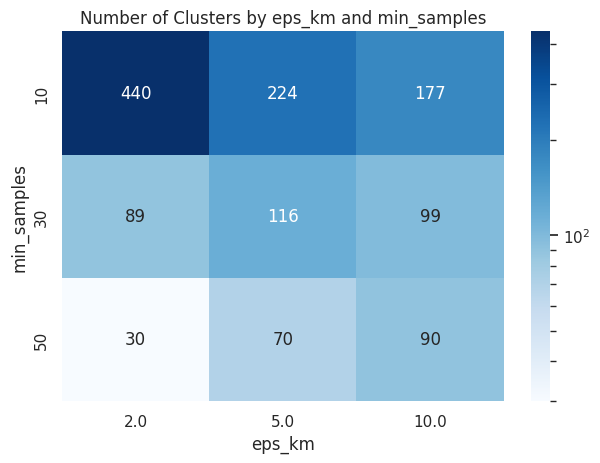

Selected parameters: eps_km=10.0, min_samples=30
Clusters: 99, Noise: 21.7%
Clusters found: 99, Noise points: 10840


In [ ]:
def run_spatial_clustering(df, eps_km=5.0, min_samples=30):

    # Cap at 50k points for performance
    work_df = df.sample(n=min(len(df), 50000), random_state=42) if len(df) > 50000 else df.copy()

    # Convert coords to radians for Haversine metric
    coords         = work_df[['Start_Lat', 'Start_Lng']].astype(float).to_numpy()
    coords_radians = np.radians(coords)

    # Calculate epsilon in radians
    eps_rad = eps_km / 6371.0088

    # Apply DBSCAN
    db     = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine', algorithm='ball_tree')
    labels = db.fit_predict(coords_radians)

    work_df['Cluster_ID'] = labels

    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = list(labels).count(-1)
    print(f"Clusters found: {n_clusters}, Noise points: {noise_count}")

    return work_df


# Run sensitivity analysis
sensitivity_results = []

for eps in [2.0, 5.0, 10.0]:
    for min_s in [10, 30, 50]:
        r = run_spatial_clustering(df, eps_km=eps, min_samples=min_s)
        sensitivity_results.append({
            'eps_km'     : eps,
            'min_samples': min_s,
            'n_clusters' : r[r['Cluster_ID'] != -1]['Cluster_ID'].nunique(),
            'noise_pct'  : round((r['Cluster_ID'] == -1).mean() * 100, 1)
        })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))

# Visualize cluster count heatmap
from matplotlib.colors import LogNorm
pivot = sens_df.pivot(index='min_samples', columns='eps_km', values='n_clusters')
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', norm=LogNorm())
plt.title('Number of Clusters by eps_km and min_samples')
plt.xlabel('eps_km')
plt.ylabel('min_samples')
plt.tight_layout()
plt.show()

# Pick optimal parameters
best = sens_df[
    (sens_df['noise_pct'] < 25) &
    (sens_df['min_samples'] >= 30)
].sort_values('noise_pct', ascending=True).iloc[0]

best_eps         = best['eps_km']
best_min_samples = int(best['min_samples'])

print(f"Selected parameters: eps_km={best_eps}, min_samples={best_min_samples}")
print(f"Clusters: {int(best['n_clusters'])}, Noise: {best['noise_pct']}%")

# Run final clustering
min_samples  = 5 if len(df) < 2000 else best_min_samples
clustered_df = run_spatial_clustering(df, eps_km=best_eps, min_samples=min_samples)

## Cluster Profiling
Every identified valid cluster is profiled to determine what makes it unique from the average sample of the entire data set. DBSCAN outliers are not considered during cluster profiling.

For every identified cluster, we get the following information:
- **Number of Accidents** – number of accidents in the cluster
- **Average Severity and Duration** – comparing against the global average of the data set
- **Most Frequent City and Weather** – identifying the dominant city and weather type
- **Unique Feature** – automatic classification of the cluster by looking at how it differs from global averages
  - Severity – if the average severity is over 20 percent greater than the global average
  - Duration – if the average duration is over 50 percent greater than the global average
  - Snowy – if snowing is the most dominant weather condition
  - Normal – otherwise

The report lists out the top 10 accident hotspot clusters by number of accidents.

In [ ]:
def profile_clusters(df):
    # Filter out noise
    valid_clusters = df[df['Cluster_ID'] != -1]
    if valid_clusters.empty:
        print("No valid clusters to profile.")
        return

    # Calculate global averages
    global_mean_sev = df['Severity'].mean()
    global_mean_dur = df['Duration_Hours'].mean() if 'Duration_Hours' in df.columns else 0

    # Aggregate cluster metrics
    profiles = valid_clusters.groupby('Cluster_ID').agg(
        Accident_Count    = ('Cluster_ID', 'count'),
        Avg_Severity      = ('Severity', 'mean'),
        Avg_Duration      = ('Duration_Hours', 'mean') if 'Duration_Hours' in df.columns else ('Severity', 'mean'),
        Dominant_City     = ('City', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
        Dominant_Weather  = ('Weather_Condition', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
    ).reset_index()

    # Identify distinguishing traits
    def get_trait(row):
        traits = []
        if row['Avg_Severity'] > global_mean_sev * 1.2:  traits.append("High Severity")
        if row['Avg_Duration'] > global_mean_dur * 1.5:   traits.append("Long Delays")
        if "Snow" in str(row['Dominant_Weather']):         traits.append("Snow Prone")
        return ", ".join(traits) if traits else "Standard Cluster"

    profiles['Distinguishing_Trait'] = profiles.apply(get_trait, axis=1)

    print("Top 10 Accident Hotspot Profiles")
    display(profiles.sort_values('Accident_Count', ascending=False).head(10))

profile_clusters(clustered_df)

Top 10 Accident Hotspot Profiles


,Cluster_ID,Accident_Count,Avg_Severity,Avg_Duration,Dominant_City,Dominant_Weather,Distinguishing_Trait
0,0,5945,2.233137,1.903193,Los Angeles,Fair,Standard Cluster
12,12,2417,2.205627,1.685540,San Jose,Fair,Standard Cluster
25,25,2049,2.172279,2.840593,Miami,Fair,Standard Cluster
7,7,1880,2.285106,2.315969,Bronx,Fair,Standard Cluster
41,41,1363,2.328687,1.596088,Dallas,Fair,Standard Cluster
22,22,1334,2.319340,1.933319,Washington,Fair,Standard Cluster
32,32,1234,2.223663,1.572283,Houston,Mostly Cloudy,Standard Cluster
2,2,1105,2.079638,1.653437,Charlotte,Fair,Standard Cluster
30,30,997,2.391174,1.729740,Chicago,Fair,Standard Cluster
5,5,916,2.112445,2.286650,Orlando,Fair,Standard Cluster


## Cluster Validation Metrics
To quantitatively confirm that the discovered clusters are meaningful and well-separated,
two standard internal validation indices are computed:

- **Silhouette Score** - This index determines similarity of the point in its own cluster as opposed to other neighboring clusters. Its range is from -1 to 1; high scores represent strong clusters. In our analysis, scores between 0.51 and 0.70 have been termed Reasonable, while scores above 0.71 are considered Strong.
- **Davies-Bouldin Index** - Measures the ration of within-cluster scatter to between-cluster separation. Lower scores are favorable. In our analysis, scores lower than 0.5 are classified as Excellent, those lower than 1.0 as Good, and those lower than 1.5 as Acceptable.

Both metrics are computed on all clustered points excluding noise (Cluster_ID = -1).
A sample is used only if the clustered point count exceeds the sample size threshold.

Sampled 20,000 points for validation.
       CLUSTER VALIDATION REPORT
  Clusters evaluated   : 99
  Points used          : 20,000
  Silhouette Score     : 0.6761  -  Reasonable
  Davies-Bouldin Index : 0.2621  -  Excellent


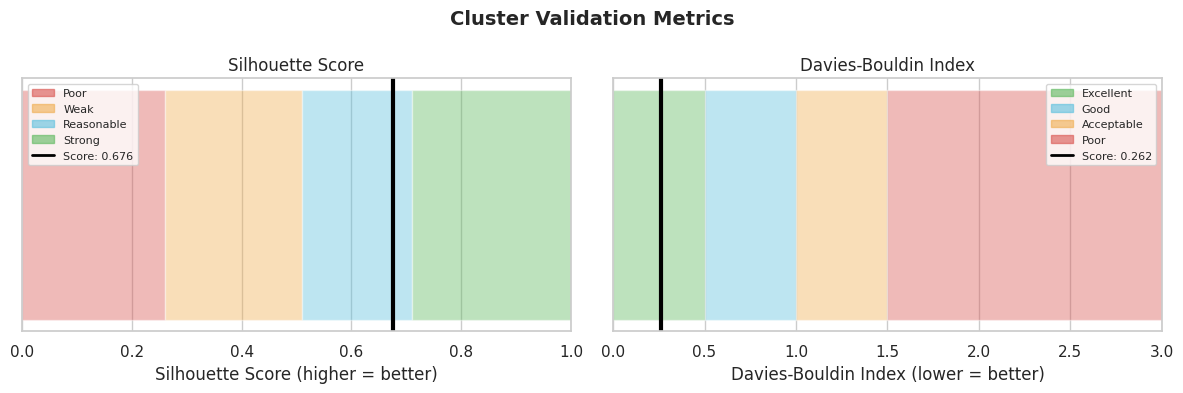

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.patches as mpatches

def validate_clusters(clustered_df, sample_size=20000):
    # Filter valid clusters
    valid      = clustered_df[clustered_df['Cluster_ID'] != -1].copy()
    n_clusters = valid['Cluster_ID'].nunique()

    if n_clusters < 2:
        print("Need at least 2 clusters to compute validation metrics.")
        return

    # Sample points to speed up metric calculation
    if len(valid) > sample_size:
        valid = valid.sample(sample_size, random_state=42)
        print(f"Sampled {sample_size:,} points for validation.")

    X      = valid[['Start_Lat', 'Start_Lng']].values
    labels = valid['Cluster_ID'].values

    # Calculate metrics
    sil_score = silhouette_score(X, labels, metric='euclidean')
    dbi_score = davies_bouldin_score(X, labels)

    # Interpret metrics
    def interpret_silhouette(s):
        if s >= 0.71: return 'Strong'
        if s >= 0.51: return 'Reasonable'
        if s >= 0.26: return 'Weak'
        return 'Poor'

    def interpret_dbi(d):
        if d < 0.5:  return 'Excellent'
        if d < 1.0:  return 'Good'
        if d < 1.5:  return 'Acceptable'
        return 'Poor'

    print("       CLUSTER VALIDATION REPORT")
    print(f"  Clusters evaluated   : {n_clusters}")
    print(f"  Points used          : {len(valid):,}")
    print(f"  Silhouette Score     : {sil_score:.4f}  -  {interpret_silhouette(sil_score)}")
    print(f"  Davies-Bouldin Index : {dbi_score:.4f}  -  {interpret_dbi(dbi_score)}")

    # Plot gauge charts
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Cluster Validation Metrics', fontsize=14, fontweight='bold')

    # Silhouette gauge
    ax1         = axes[0]
    thresholds  = [0, 0.26, 0.51, 0.71, 1.0]
    sil_colors  = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
    labels_sil  = ['Poor', 'Weak', 'Reasonable', 'Strong']
    for j in range(len(sil_colors)):
        ax1.barh(0, thresholds[j+1] - thresholds[j], left=thresholds[j],
                 color=sil_colors[j], height=0.4, alpha=0.4)
    ax1.axvline(sil_score, color='black', linewidth=3)
    ax1.set_xlim(0, 1)
    ax1.set_yticks([])
    ax1.set_xlabel('Silhouette Score (higher = better)')
    ax1.set_title('Silhouette Score')
    sil_patches = [mpatches.Patch(color=sil_colors[j], alpha=0.6, label=labels_sil[j]) for j in range(4)]
    ax1.legend(handles=sil_patches + [plt.Line2D([0],[0], color='black', lw=2, label=f'Score: {sil_score:.3f}')],
               loc='upper left', fontsize=8)

    # Davies-Bouldin gauge
    ax2           = axes[1]
    db_thresholds = [0, 0.5, 1.0, 1.5, 3.0]
    db_colors     = ['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f']
    db_labels     = ['Excellent', 'Good', 'Acceptable', 'Poor']
    for j in range(len(db_colors)):
        ax2.barh(0, db_thresholds[j+1] - db_thresholds[j], left=db_thresholds[j],
                 color=db_colors[j], height=0.4, alpha=0.4)
    ax2.axvline(min(dbi_score, 2.9), color='black', linewidth=3)
    ax2.set_xlim(0, 3)
    ax2.set_yticks([])
    ax2.set_xlabel('Davies-Bouldin Index (lower = better)')
    ax2.set_title('Davies-Bouldin Index')
    db_patches = [mpatches.Patch(color=db_colors[j], alpha=0.6, label=db_labels[j]) for j in range(4)]
    ax2.legend(handles=db_patches + [plt.Line2D([0],[0], color='black', lw=2, label=f'Score: {dbi_score:.3f}')],
               loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

    return {'silhouette': sil_score, 'davies_bouldin': dbi_score}

validation_results = validate_clusters(clustered_df)

## Alternative Method: K-Means
K-means was considered as an alternate solution for clustering, while DBSCAN was chosen because of the following reasons:
- Requires specifying the number of clusters upfront, which is unknown for geographic data
- Assumes spherical clusters of equal size, which does not reflect real accident hotspot shapes
- Cannot identify noise points - every accident is forced into a cluster regardless of isolation

Silhouette scores are compared below to quantitatively confirm which method produces
better-separated clusters on this dataset.

In [ ]:
from sklearn.cluster import KMeans

# Sample dataset for performance
work_df   = df.sample(n=min(len(df), 50000), random_state=42)
coords    = work_df[['Start_Lat', 'Start_Lng']].values

# Run K-Means with 20 clusters
kmeans    = KMeans(n_clusters=20, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(coords)
km_sil    = silhouette_score(coords, km_labels, metric='euclidean')

# Retrieve DBSCAN silhouette score
dbscan_sil = validation_results['silhouette']

print("METHOD COMPARISON: K-Means vs DBSCAN")
print(f"K-Means Silhouette Score : {km_sil:.4f}")
print(f"DBSCAN  Silhouette Score : {dbscan_sil:.4f}")

METHOD COMPARISON: K-Means vs DBSCAN
K-Means Silhouette Score : 0.5976
DBSCAN  Silhouette Score : 0.6761


## Categorized Outlier Detection
Extreme accident events are identified using Z-score analysis across three key metrics.
Any record with an absolute Z-score above 3 (more than 3 standard deviations from the mean) is flagged as an outlier.

The three outlier categories are:
- **Duration Anomaly** - accidents with abnormally long resolution times
- **Extreme Weather** - accidents occurring at extreme temperatures
- **Poor Visibility** - accidents where there is an unusual level of visibility, often indicating poor visibility

Results are visualized by category and by state to identify geographic concentration of extreme events.

Detected 15907 distinct outlier events.
Outlier Summary by Category


,count
Category,
Poor Visibility,13459
Extreme Weather,2170
Duration Anomaly,278


Sample of Extreme Events


,ID,State,Category,Extreme_Value,Metric
0,A-4795971,LA,Duration Anomaly,8761.75,Duration_Hours
1,A-6761935,KY,Duration Anomaly,1218.10,Duration_Hours
2,A-5809998,LA,Duration Anomaly,8761.75,Duration_Hours
3,A-3887188,LA,Duration Anomaly,8761.75,Duration_Hours
4,A-5599805,LA,Duration Anomaly,8761.75,Duration_Hours


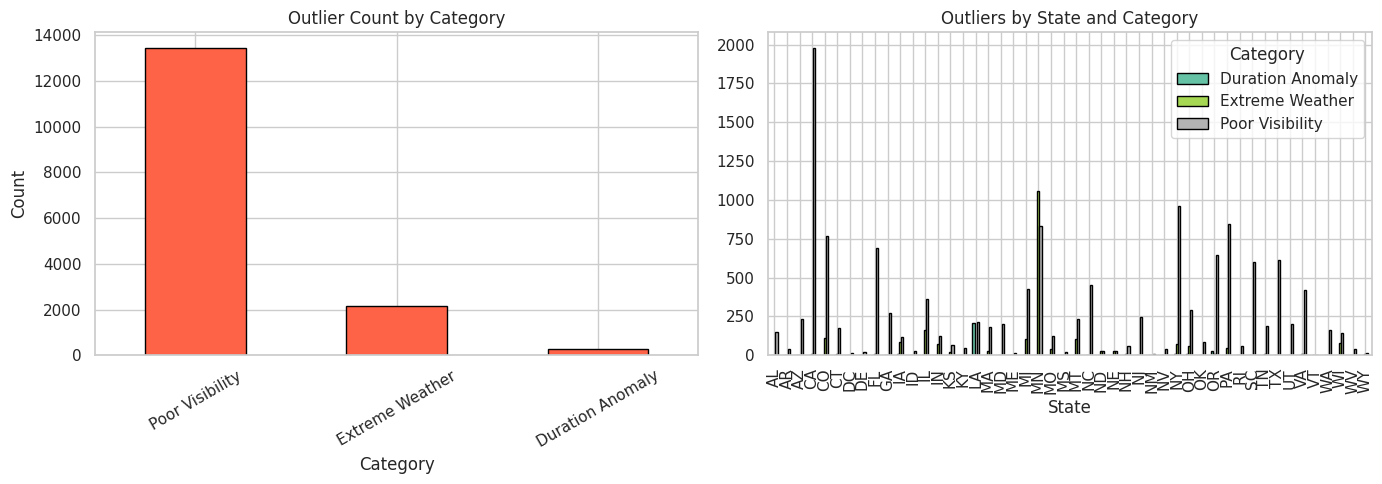

In [ ]:
def detect_and_categorize_outliers(df):
    work_df = df.copy()

    # Define metrics and outlier categories
    metrics = {
        'Duration_Hours' : 'Duration Anomaly',
        'Temperature(F)' : 'Extreme Weather',
        'Visibility(mi)' : 'Poor Visibility'
    }

    outlier_records = []

    # Find absolute Z-scores > 3 for each metric
    for col, label in metrics.items():
        if col in work_df.columns:
            z_scores    = np.abs(stats.zscore(work_df[col], nan_policy='omit'))
            outlier_idx = work_df.index[z_scores > 3]
            for idx in outlier_idx:
                outlier_records.append({
                    'ID'           : work_df.loc[idx, 'ID'] if 'ID' in work_df.columns else idx,
                    'State'        : work_df.loc[idx, 'State'],
                    'Category'     : label,
                    'Extreme_Value': work_df.loc[idx, col],
                    'Metric'       : col
                })

    # Compile unique outliers
    outliers_df = pd.DataFrame(outlier_records).drop_duplicates(subset=['ID', 'Category'])

    print(f"Detected {len(outliers_df)} distinct outlier events.")

    if not outliers_df.empty:
        print("Outlier Summary by Category")
        display(outliers_df['Category'].value_counts())

        print("Sample of Extreme Events")
        display(outliers_df.head())

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Plot outliers count per category
        outliers_df['Category'].value_counts().plot(
            kind='bar', ax=axes[0], color='tomato', edgecolor='black')
        axes[0].set_title('Outlier Count by Category')
        axes[0].set_xlabel('Category')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=30)

        # Plot outliers by state and category
        outliers_df.groupby(['State', 'Category']).size().unstack(fill_value=0).plot(
            kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
        axes[1].set_title('Outliers by State and Category')
        axes[1].set_xlabel('State')
        axes[1].tick_params(axis='x', rotation=90)

        plt.tight_layout()
        plt.show()

detect_and_categorize_outliers(df)

## Visualizations
Two analytical charts summarizing accident patterns across states:
- **Heatmap** - accident frequency by hour of day for each state, revealing peak accident periods
- **Horizontal bar chart** - total accident count per state colored by average severity,
  identifying which states have both high volume and high severity

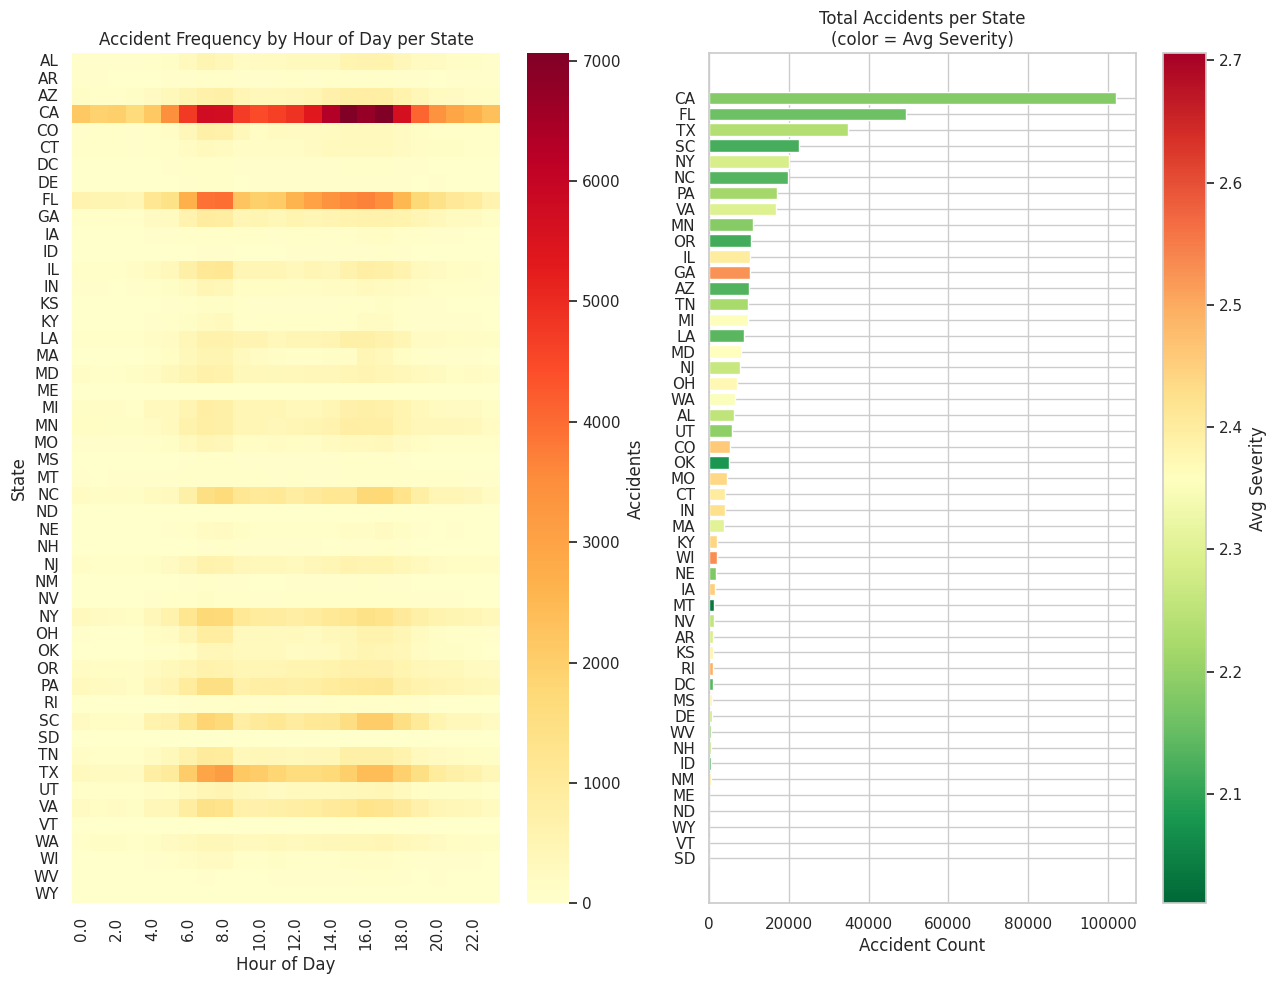

In [ ]:
def generate_plots(df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 10))

    # Heatmap: Accidents by state and hour
    hour_state = df.groupby(['State', 'Hour']).size().unstack(fill_value=0)
    sns.heatmap(hour_state, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Accidents'})
    axes[0].set_title('Accident Frequency by Hour of Day per State')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('State')

    # Bar chart: Total accidents per state
    state_stats = df.groupby('State').agg(
        Total        = ('Severity', 'count'),
        Avg_Severity = ('Severity', 'mean')
    ).sort_values('Total', ascending=True)

    # Color scale based on severity
    norm   = plt.Normalize(state_stats['Avg_Severity'].min(), state_stats['Avg_Severity'].max())
    colors = plt.cm.RdYlGn_r(norm(state_stats['Avg_Severity']))
    axes[1].barh(state_stats.index, state_stats['Total'], color=colors)
    axes[1].set_title('Total Accidents per State\n(color = Avg Severity)')
    axes[1].set_xlabel('Accident Count')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
    plt.colorbar(sm, ax=axes[1], label='Avg Severity')

    plt.tight_layout()
    plt.show()

generate_plots(df)

## Interactive Geospatial Hotspot Map
This interactive geospatial map, created using Folium, displays all non-noise clustered accident points from all over the country.
The FastMarkerCluster is used to deal effectively with high numbers of points.


In [ ]:
def generate_map(clustered_df):
    from folium.plugins import FastMarkerCluster

    # Filter out noise points
    map_df = clustered_df[clustered_df['Cluster_ID'] != -1].copy()

    if map_df.empty:
        print("No clustered points available to map.")
        return

    print(f"Mapping {len(map_df):,} clustered accident points.")

    # Center map
    center_lat = map_df['Start_Lat'].mean()
    center_lng = map_df['Start_Lng'].mean()
    m = folium.Map(location=[center_lat, center_lng], zoom_start=5, tiles='CartoDB positron')

    # Add points via FastMarkerCluster
    coords = map_df[['Start_Lat', 'Start_Lng']].values.tolist()
    FastMarkerCluster(coords).add_to(m)
    display(m)

generate_map(clustered_df)

Mapping 39,160 clustered accident points.


## Baseline Comparison: Grid-based Hotspot Detection
A naive grid-based baseline is used to justify the added complexity of DBSCAN.
The US accident coordinates are binned into uniform 0.5 degree latitude-longitude grid cells. and the top 10% most
accident-dense cells are flagged as hotspots.

Key limitations of the grid approach compared to DBSCAN:
- Grid cells are fixed-size and ignore natural accident density boundaries
- Different spatial patterns may be aggregated into the same grid cells
- DBSCAN adapts to actual data density and separates noise from true hotspots

BASELINE vs DBSCAN COMPARISON
Grid Baseline : 241 hotspot grid cells
DBSCAN        : 99 clusters


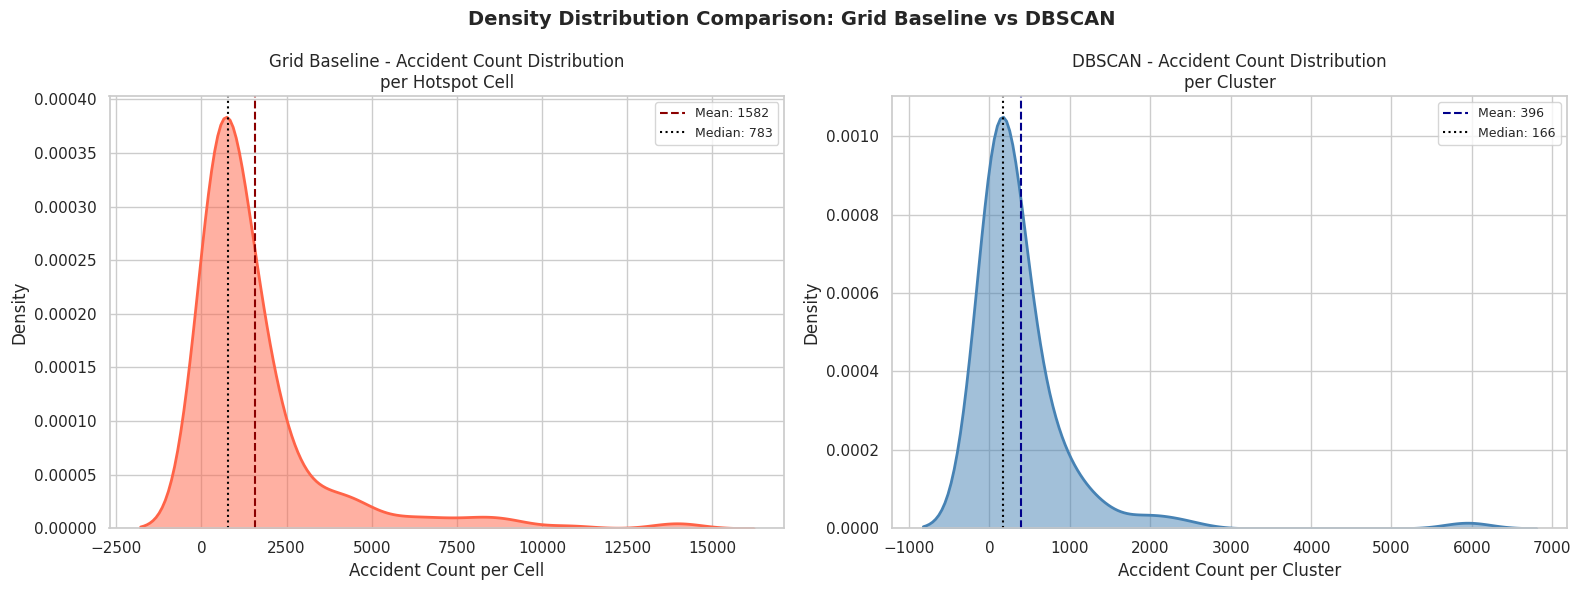

In [ ]:
def grid_baseline(df, grid_size=0.5):
    df = df.copy()

    # Bin coordinates into grids
    df['lat_bin'] = (df['Start_Lat'] // grid_size) * grid_size
    df['lng_bin'] = (df['Start_Lng'] // grid_size) * grid_size

    grid_counts = df.groupby(['lat_bin', 'lng_bin']).size().reset_index(name='count')

    # Find top 10% hotspots
    threshold = grid_counts['count'].quantile(0.90)
    hotspots  = grid_counts[grid_counts['count'] >= threshold]

    print("BASELINE vs DBSCAN COMPARISON")
    print(f"Grid Baseline : {len(hotspots)} hotspot grid cells")
    print(f"DBSCAN        : {clustered_df[clustered_df['Cluster_ID'] != -1]['Cluster_ID'].nunique()} clusters")

    # Get DBSCAN cluster counts
    dbscan_counts = clustered_df[clustered_df['Cluster_ID'] != -1].groupby('Cluster_ID').size().reset_index(name='count')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Density Distribution Comparison: Grid Baseline vs DBSCAN', fontsize=14, fontweight='bold')

    # Baseline KDE plot
    sns.kdeplot(hotspots['count'], ax=axes[0], fill=True,
                color='tomato', alpha=0.5, linewidth=2)
    axes[0].axvline(hotspots['count'].mean(), color='darkred',
                    linestyle='--', linewidth=1.5, label=f"Mean: {hotspots['count'].mean():.0f}")
    axes[0].axvline(hotspots['count'].median(), color='black',
                    linestyle=':', linewidth=1.5, label=f"Median: {hotspots['count'].median():.0f}")
    axes[0].set_title('Grid Baseline - Accident Count Distribution\nper Hotspot Cell')
    axes[0].set_xlabel('Accident Count per Cell')
    axes[0].set_ylabel('Density')
    axes[0].legend(fontsize=9)

    # DBSCAN KDE plot
    sns.kdeplot(dbscan_counts['count'], ax=axes[1], fill=True,
                color='steelblue', alpha=0.5, linewidth=2)
    axes[1].axvline(dbscan_counts['count'].mean(), color='darkblue',
                    linestyle='--', linewidth=1.5, label=f"Mean: {dbscan_counts['count'].mean():.0f}")
    axes[1].axvline(dbscan_counts['count'].median(), color='black',
                    linestyle=':', linewidth=1.5, label=f"Median: {dbscan_counts['count'].median():.0f}")
    axes[1].set_title('DBSCAN - Accident Count Distribution\nper Cluster')
    axes[1].set_xlabel('Accident Count per Cluster')
    axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return hotspots

baseline_hotspots = grid_baseline(df)